Question 1

In [1]:
import math
#
from scipy.optimize import minimize_scalar
# Coordinate descent for minimisation
def coordinate_descent(f, argmin, x_t0, max_iter=25):
  # track f
  f_values = []
  #initialisation of starting point
  xt = x_t0.copy()
  # The outer loop that iterates on t
  for t in range(max_iter):
    # The inner loop that iterates on i
    for i in range(len(xt)):
      xt[i] = argmin[i](xt)
    f_values.append(f(xt))
  return xt, f_values

# Define function f
def f(x):
  return (math.exp(x[0] - 3 * x[1] + 3) + math.exp(3 * x[1] - 2 * x[2] - 2) + math.exp(2 * x[2] - x[0] + 2))

# Define argmin funciton for x1
def argmin_x1(x):
  def g(x1):
    return math.exp(x1 - 3 * x[1] + 3) + math.exp(2 * x[2] - x1 + 2)
  result = minimize_scalar(g)
  return result.x

# Define argmin function for x2
def argmin_x2(x):
  def g(x2):
    return math.exp(x[0] - 3 * x2 + 3) + math.exp(3 * x2 - 2 * x[2] - 2)
  result = minimize_scalar(g)
  return result.x

# Define argmin function for x3
def argmin_x3(x):
  def g(x3):
    return math.exp(3 * x[1] - 2 * x3 - 2) + math.exp(2 * x3 -x[0] + 2)
  result = minimize_scalar(g)
  return result.x

argmin = [argmin_x1, argmin_x2, argmin_x3]

x_t0 = [1, 20, 5]

x_final, f_values = coordinate_descent(f, argmin, x_t0, max_iter = 25)

print("final coordinate:")
print("x1 = ", x_final[0])
print("x2 = ", x_final[1])
print("x3 = ", x_final[2])
print("\nfinal function value: ")
print("f(x) = ", f_values[-1])

print(f_values)


final coordinate:
x1 =  26.666667919513618
x2 =  9.555555977996113
x3 =  12.83333404261666

final function value: 
f(x) =  8.154845485377205
[344551.9083494794, 11.956555377466408, 8.225815693505124, 8.155915133996965, 8.154862270050202, 8.154845747519712, 8.15484548947047, 8.154845485441532, 8.154845485378164, 8.154845485377226, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205, 8.154845485377205]


# Question 2

In [2]:
import math

"""
Gradient descent for minimisation, def gradient_descent

This function follows the same format for gradient descent as introduced in the
lecture, and also in the book for the course. It takes the Himmelblau function,
its gradient, initial point (u_0, v_0), step size, and max iterations as input.
It has a for loop which has max_iter iterations, where at each step t it
computes the gradient at the current point, takes a step in the negative
gradient direction scaled by eta(t), and records the current point and function
value before updating.

input param: f, grad_f, eta, u0, v0, max_iter=100
return: two lists, uv_values containing the (u, v) point values at each iteration,
f_values containing the function values evaluated at those points

"""

def gradient_descent(f, grad_f, eta, u0, v0, max_iter=100) -> tuple[list, list]:
  uv_values = []
  f_values = []
  # Initialisation of x_0 using u0, v0
  xt = (u0, v0)
  # Now we have the for loop which iterates t
  for t in range(max_iter):
    step = eta(t)
    gradt = grad_f(xt[0], xt[1])
    xt1 = (xt[0] - step * gradt[0], xt[1] - step * gradt[1])
    uv_values.append(xt)
    f_values.append(f(xt[0], xt[1]))
    xt = xt1
  return (uv_values, f_values)

# Himmelblau function and its gradient
def himmelblau(u, v):
  f = (u**2 + v - 11)**2 + (u + v**2 - 7)**2
  return f

def himmelblau_grad(u, v):
  grad_f = (4*u * (u**2 + v - 11) + 2 * (u + v**2 -7), 2 * (u**2 + v - 11) + 4*v * (u + v**2 -7))
  return grad_f

# eta function 2a
def eta_const(t, c=1e-3):
    return c

# eta function 2b
def eta_sqrt(t, c=1e-3) -> float:
  eta = c / math.sqrt(t + 1)
  return eta

# eta function 2c
def eta_multistep(t, milestones=[30, 80, 100], c=1e-3, eta_init=1e-3) -> float:
  eta = eta_init
  for milestone in milestones:
    if t >= milestone:
      eta = eta * c
  return eta


# printing answers for each part
path, f_vals = gradient_descent(himmelblau, himmelblau_grad, eta_const, u0=4, v0=-5) #2a
print(f"(2a) final f = {f_vals[-1]}, min f = {min(f_vals)}")

path, f_vals = gradient_descent(himmelblau, himmelblau_grad, eta_sqrt, u0=4, v0=-5) #2b
print(f"(2b) final f = {f_vals[-1]}, min f = {min(f_vals)}")

path, f_vals = gradient_descent(himmelblau, himmelblau_grad, eta_multistep, u0=4, v0=-5) #2c
print(f"(2c) final f = {f_vals[-1]}, min f = {min(f_vals)}")

print()

path, f_vals = gradient_descent(himmelblau, himmelblau_grad, eta_const, u0=-4, v0=0, max_iter=100)
print(f"(2d) point (-4, 0): final point = {path[-1]}, final f = {f_vals[-1]}, min f = {min(f_vals)}")

path, f_vals = gradient_descent(himmelblau, himmelblau_grad, eta_const, u0=0, v0=0, max_iter=100)
print(f"(2d) point (0, 0): final point = {path[-1]}, final f = {f_vals[-1]}, min f = {min(f_vals)}")

path, f_vals = gradient_descent(himmelblau, himmelblau_grad, eta_const, u0=4, v0=0, max_iter=100)
print(f"(2d) point (4, 0): final point = {path[-1]}, final f = {f_vals[-1]}, min f = {min(f_vals)}")

path, f_vals = gradient_descent(himmelblau, himmelblau_grad, eta_const, u0=0, v0=4, max_iter=100)
print(f"(2d) point (0, 4): final point = {path[-1]}, final f = {f_vals[-1]}, min f = {min(f_vals)}")

path, f_vals = gradient_descent(himmelblau, himmelblau_grad, eta_const, u0=5, v0=5, max_iter=100)
print(f"(2d) point (5, 5): final point = {path[-1]}, final f = {f_vals[-1]}, min f = {min(f_vals)}")


(2a) final f = 0.030757893214651656, min f = 0.030757893214651656
(2b) final f = 13.016806298551181, min f = 13.016806298551181
(2c) final f = 3.683838858524812, min f = 3.683838858524812

(2d) point (-4, 0): final point = (-3.149649717617326, -0.7010569379966464), final f = 96.45134523450776, min f = 96.45134523450776
(2d) point (0, 0): final point = (2.903667680126649, 2.0945426866069248), final f = 0.3093895537566177, min f = 0.3093895537566177
(2d) point (4, 0): final point = (3.4495710470902945, -0.4745142018151888), final f = 11.238036094556296, min f = 11.238036094556296
(2d) point (0, 4): final point = (-2.344030662140015, 3.098350258831782), final f = 5.8598722120101145, min f = 5.8598722120101145
(2d) point (5, 5): final point = (2.9817393942779757, 2.0424972168012476), final f = 0.028026062567519532, min f = 0.028026062567519532


Question 3

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

df = pd.read_csv('california_housing_with_split.csv')
feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X_train = df[df['split'] == 'train'][feature_names].to_numpy()
X_test  = df[df['split'] == 'test'][feature_names].to_numpy()
y_train = df[df['split'] == 'train']['MedHouseVal'].to_numpy()
y_test  = df[df['split'] == 'test']['MedHouseVal'].to_numpy()

# ── 3a: Linear Regression ──────────────────────────────────────────────────

# Prepend a column of 1s to X so the dot product includes the intercept term (β0)
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

beta_lin  = np.linalg.lstsq(X_train_b, y_train, rcond=None)[0]
mse_lin   = mean_squared_error(y_test, X_test_b @ beta_lin)

# Map feature names → coefficient indices (offset by 1 because index 0 is the bias)
feat_idx = {name: i+1 for i, name in enumerate(feature_names)}

print("=== Linear Regression ===")
print(f"βMedInc    = {beta_lin[feat_idx['MedInc']]:.6f}")
print(f"βAveBedrms = {beta_lin[feat_idx['AveBedrms']]:.6f}")
print(f"βHouseAge  = {beta_lin[feat_idx['HouseAge']]:.6f}")
print(f"MSE (test) = {mse_lin:.6f}")

# ── 3a: Polynomial Regression  ───────────────────────────────────

# Standardize features (zero mean, unit variance) before polynomial expansion
# to prevent large-magnitude features from dominating the higher-degree terms
scaler = StandardScaler()

# Fit poly on scaled training data
X_train_poly = PolynomialFeatures(degree=2, include_bias=True).fit_transform(scaler.fit_transform(X_train))

poly         = PolynomialFeatures(degree=2, include_bias=True).fit(scaler.transform(X_train))
X_train_poly = poly.transform(scaler.transform(X_train))
X_test_poly  = poly.transform(scaler.transform(X_test))

# OLS solution on the expanded (degree-2) feature matrix
beta_poly         = np.linalg.lstsq(X_train_poly, y_train, rcond=None)[0]
poly_feature_names = poly.get_feature_names_out(feature_names)

# Helper: look up a coefficient by its feature name (e.g. 'MedInc AveBedrms' for interaction term)
def get_coef(name):
    return beta_poly[list(poly_feature_names).index(name)]

print("\n=== Polynomial Regression (degree 2) ===")
print(f"βMedInc             = {get_coef('MedInc'):.6f}")
print(f"βMedInc·AveBedrms   = {get_coef('MedInc AveBedrms'):.6f}")
print(f"βHouseAge·AveBedrms = {get_coef('HouseAge AveBedrms'):.6f}")
print(f"MSE (test)          = {mean_squared_error(y_test, X_test_poly @ beta_poly):.6f}")

# ── 3b: Ridge Regression (λ=0.001) ────────────────

lam = 0.001
n, d = X_train_poly.shape

# Identity penalty matrix — bias term (index 0) is excluded from regularization
# so the intercept is not shrunk toward zero
penalty    = np.eye(d); penalty[0, 0] = 0

# Ridge closed-form: β = (XᵀX + n·λ·I)⁻¹Xᵀy
# The n·λ term adds to the diagonal, making the matrix invertible and shrinking coefficients
beta_ridge = np.linalg.solve(X_train_poly.T @ X_train_poly + n * lam * penalty, X_train_poly.T @ y_train)

def get_coef_ridge(name):
    return beta_ridge[list(poly_feature_names).index(name)]

print("\n=== Ridge Regression (degree 2, λ=0.001) ===")
print(f"βMedInc             = {get_coef_ridge('MedInc'):.6f}")
print(f"βMedInc·AveBedrms   = {get_coef_ridge('MedInc AveBedrms'):.6f}")
print(f"βHouseAge·AveBedrms = {get_coef_ridge('HouseAge AveBedrms'):.6f}")
print(f"MSE (test)          = {mean_squared_error(y_test, X_test_poly @ beta_ridge):.6f}")

=== Linear Regression ===
βMedInc    = 0.448675
βAveBedrms = 0.783145
βHouseAge  = 0.009724
MSE (test) = 0.555892

=== Polynomial Regression (degree 2) ===
βMedInc             = 0.935940
βMedInc·AveBedrms   = -0.120152
βHouseAge·AveBedrms = 0.052345
MSE (test)          = 0.464302

=== Ridge Regression (degree 2, λ=0.001) ===
βMedInc             = 0.943703
βMedInc·AveBedrms   = -0.115015
βHouseAge·AveBedrms = 0.060710
MSE (test)          = 0.445156


# Question 4

In [ ]:
import math
import numpy as np

# for part 4a, we want to compute the log-conditional probabilities with laplace smoothing

alpha = 1e-5 # laplace smoothing parameter
num_classes = 4

D = vectorizer.fit_transform(df['text']) # assuming 'text' is the column with the documents

words = vectorizer.get_feature_names_out()
col_chip = np.where(words == 'chip')[0][0] # column index for 'chip' word

chip_col_data = D[:, col_chip].toarray().flatten() # indicator if chip is in document

print("4a answers (in order from 0 to 3):")
for l in range(num_classes):
  cond = (y_train == l) # this is the condition of the probability
  total_doc = np.sum(cond) # total documents in class l
  total_doc_chip = np.sum(chip_col_data[cond]) # class l docs with 'chip'
  smoothed_prob = (total_doc_chip + alpha) / (total_doc + 2 * alpha)
  log_prob = np.log(smoothed_prob)

  print(f"log p(x_'chip'=1 | y={l}) = {log_prob}")


# now we move onto part 4b, where we want the posterior probabilities

# compute class frequency p(y=l)
print("4b answers (in order from 0 to 3):")
total_docs = len(y_train)
doc_p = np.zeros(num_classes)
for l in range(num_classes):
  doc_p[l] = np.sum(y_train == l) / total_docs

# query words
q_words = {'electronics' : 0, 'sale' : 1, 'games' : 2, 'ball' : 3}
for word, q_class in q_words.items():
  col = np.where(words == word)[0][0]
  word_col_data = D[:, col].toarray().flatten()

  # compute likelihood p(x_word=1 | y=l) for each class with Laplace smoothing
  p_x_given_y = np.zeros(num_classes)

  for l in range(num_classes):
    cond = (y_train == l)
    total_doc = np.sum(cond)
    total_doc_word = np.sum(word_col_data[cond])

    p_x_given_y[l] = (total_doc_word + alpha) / (total_doc + 2 * alpha)

  numerator = doc_p[q_class] * p_x_given_y[q_class]
  denominator = np.sum(doc_p * p_x_given_y)

  # Bayes: posterior = class freq * likelihood / marginal
  posterior = numerator / denominator
  print(f"p(y={q_class} | x_'{word}'=1) = {posterior}")


KeyError: 'text'

# Question 5

### Imports for dependencies

In [5]:
import pandas as pd
import numpy as np

### Load Data

In [6]:
df = pd.read_csv("train.csv")
y = df['Survived']

### Setup Information Gain (IG) using Gini Impurity

In [7]:
def gini(labels):
    # labels: array of 0s (died) and 1s (survived) for a group of passengers
    # returns 0 if the group is empty (no passengers to evaluate)
    if len(labels) == 0:
        return 0
    p = np.mean(labels) # fraction of survivors

    return 1 - p**2 - (1 - p)**2
    # = 0 if group is pure (all survived or all died)
    # = 0.5 if group is maximally mixed (50/50 split)

def weighted_gini(left, right):
    # Total number of passengers across both child groups
    n = len(left) + len(right)

    # Weight each child's Gini score by its proportion of the total
    return (len(left) / n) * gini(left) + (len(right) / n) * gini(right)

def information_gain(y, left_mask):
    # left_mask: boolean array — True for passengers going to the left child

    # ~ flips the boolean mask to get the right child group
    right_mask = ~left_mask
    return gini(y) - weighted_gini(y[left_mask], y[right_mask])

### Compute Information Gain (IG) using Gini Impurity

In [8]:
# Check how many values are missing for each feature we will use
features = ['Sex', 'Pclass', 'Fare', 'Age', 'Embarked']
print(df[features].isnull().sum())
print()

# SEX  (discrete feature — split on each unique value)
mask_female = df['Sex'] == 'female'
ig_sex = information_gain(y, mask_female)
print(f"Sex:  split = female | male,  IG = {ig_sex:.6f}")

# PCLASS  (discrete: try each unique value as the "left" group)
# Initialise trackers for the best split found so far
best_ig_pclass, best_val_pclass = -1, None

for val in df['Pclass'].unique():
    # Boolean mask: True for passengers in this class, False for all others
    ig = information_gain(y, df['Pclass'] == val)
    print(f"  Pclass={val}: IG = {ig:.6f}")

    # Update best if this split is better than anything seen so far
    if ig > best_ig_pclass:
        best_ig_pclass, best_val_pclass = ig, val
print(f"Pclass best:  Pclass = {best_val_pclass}, IG = {best_ig_pclass:.6f}\n")

# FARE  (continuous; try midpoints between consecutive sorted unique values)
obs          = df['Fare'].notna()   # boolean mask: non-missing rows
y_fare       = y[obs]               # labels for those rows
fare_vals    = df.loc[obs, 'Fare'].values
sorted_vals  = np.sort(np.unique(fare_vals))
midpoints    = (sorted_vals[:-1] + sorted_vals[1:]) / 2   # midpoints

# Initialise trackers for the best split found so far
best_ig_fare, best_mp_fare = -1, None

for mp in midpoints:
    # True for passengers with Fare >= threshold (left group)
    # False for passengers with Fare < threshold (right group)
    mask = df.loc[obs, 'Fare'] >= mp
    ig   = information_gain(y_fare, mask.values)

    # Update best if this midpoint gives a higher IG
    if ig > best_ig_fare:
        best_ig_fare, best_mp_fare = ig, mp

print(f"Fare best:  Fare >= {best_mp_fare:.4f},  IG = {best_ig_fare:.6f}\n")

# AGE  (continuous — same midpoint approach, skip NaN rows)
# Boolean mask for rows where Age is not NaN
obs          = df['Age'].notna()

# Subset of labels aligned to only the non-missing Age rows
y_age        = y[obs]
age_vals     = df.loc[obs, 'Age'].values
sorted_vals  = np.sort(np.unique(age_vals))
midpoints    = (sorted_vals[:-1] + sorted_vals[1:]) / 2

# Initialise trackers for the best split found so far
best_ig_age, best_mp_age = -1, None

for mp in midpoints:
    # True for passengers with Age >= threshold (left group)
    mask = df.loc[obs, 'Age'] >= mp
    ig   = information_gain(y_age, mask.values)

    # Update best if this midpoint gives a higher IG
    if ig > best_ig_age:
        best_ig_age, best_mp_age = ig, mp
print(f"Age best:  Age >= {best_mp_age:.4f},  IG = {best_ig_age:.6f}\n")

# EMBARKED  (discrete — try each unique value, skip NaN rows)
# Boolean mask for rows where Embarked is not NaN
obs    = df['Embarked'].notna()

# Subset of labels aligned to only the non-missing Embarked rows
y_emb  = y[obs]

# Initialise trackers for the best split found so far
best_ig_emb, best_val_emb = -1, None

for val in df.loc[obs, 'Embarked'].unique():
    # True for passengers who embarked at this port, False for all others
    mask = df.loc[obs, 'Embarked'] == val
    ig   = information_gain(y_emb, mask.values)
    print(f"  Embarked={val}: IG = {ig:.6f}")

    # Update best if this port gives a higher IG
    if ig > best_ig_emb:
        best_ig_emb, best_val_emb = ig, val
print(f"Embarked best:  Embarked = {best_val_emb},  IG = {best_ig_emb:.6f}")

Sex           0
Pclass        0
Fare          0
Age         177
Embarked      2
dtype: int64

Sex:  split = female | male,  IG = 0.139648
  Pclass=3: IG = 0.049138
  Pclass=1: IG = 0.038665
  Pclass=2: IG = 0.004122
Pclass best:  Pclass = 3, IG = 0.049138

Fare best:  Fare >= 10.4812,  IG = 0.042584

Age best:  Age >= 6.5000,  IG = 0.012345

  Embarked=S: IG = 0.010882
  Embarked=C: IG = 0.013646
  Embarked=Q: IG = 0.000010
Embarked best:  Embarked = C,  IG = 0.013646


# Question 6a

### Imports for dependencies


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import warnings

### Load data from CSV into dataframes

In [11]:
df = pd.read_csv("METABRIC_RNA_Mutation.csv")
df_D = pd.concat([df['age_at_diagnosis'], df.iloc[:, 31:520]], axis=1)
D = df_D.to_numpy()
y = df['overall_survival_months'].to_numpy()

C:\Users\20243325\AppData\Local\Temp\ipykernel_45576\3143499551.py:1: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("METABRIC_RNA_Mutation.csv")


### Create the design matrix `X`

In [12]:
n_samples = D.shape[0]
X = np.c_[np.ones(n_samples), D] # add a column of ones for bias term

### Implementing Ridge Regression

In [13]:
def fit_ridge(X, y, lambda_val):
    """Fit ridge regression using the closed-form solution."""
    # n = number of training samples
    # d = number of features
    n = X.shape[0]
    d = X.shape[1]

    # Create a d×d identity matrix, then set the top-left entry to 0
    I_star = np.eye(d)
    I_star[0, 0] = 0

    # Scaling by n ensures the penalty is consistent regardless of dataset size
    penalty = 2 * n * lambda_val * I_star

    # Compute beta: (X^T X + penalty)^(-1) X^T y
    X_T_X = np.dot(X.T, X)
    beta = np.linalg.solve(X_T_X + penalty, np.dot(X.T, y))

    return beta

def predict_ridge(X, beta):
    # Prediction is simply the dot product of the design matrix and coefficients
    return np.dot(X, beta)

predict_ridge(X, fit_ridge(X, y, 1))

array([ 99.80309831, 144.41418686, 137.28781668, ...,  91.05392227,
       125.23857602, 148.16050204], shape=(1904,))

### Cross-validation & Lasso Regression

In [15]:
# 30 lambda values spaced logarithmically from 1e-10 to 8
lambdas = np.logspace(-10, np.log10(8), num=30)

# 5-fold cross-validation: splits data into 5 equal parts
# shuffle=True randomises order before splitting; random_state fixes the seed
kf = KFold(n_splits=5, shuffle=True, random_state=45)

# Lists to store the average MSE across folds for each lambda value
ridge_train_mse, ridge_test_mse = [], []
lasso_train_mse, lasso_test_mse, lasso_features_count = [], [], []

# Track how many features each model uses at each lambda
ridge_features_count = []

print("Starting cross-validation...may take a moment.")

# tqdm wraps the loop to show a progress bar in the notebook
for lambda_value in tqdm(lambdas):
    # Temporary lists to store results across the 5 folds
    fold_ridge_train, fold_ridge_test = [], []
    fold_lasso_train, fold_lasso_test, fold_features = [], [], []
    fold_ridge_features = []

    # Initialise the Lasso model for this lambda value
    lasso_model = Lasso(alpha=lambda_value, fit_intercept=False,
                        max_iter=10000)

    for train_idx, test_idx in kf.split(X):
        # Slice X and y into train and test sets for this fold
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Process Ridge
        # Fit ridge using our closed-form solution on the training fold
        beta_ridge = fit_ridge(X_train, y_train, lambda_value)

        # Predict on both train and test sets
        pred_train_ridge = predict_ridge(X_train, beta_ridge)
        pred_test_ridge = predict_ridge(X_test, beta_ridge)

        # Record MSE for this fold
        fold_ridge_train.append(mean_squared_error(y_train, pred_train_ridge))
        fold_ridge_test.append(mean_squared_error(y_test, pred_test_ridge))
        fold_ridge_features.append(np.sum(np.abs(beta_ridge[1:]) > 1e-16))

        # Process Lasso
        with warnings.catch_warnings():
            # Suppress convergence warnings that often happen at
            # very low lambdas
            warnings.simplefilter("ignore")
            lasso_model.fit(X_train, y_train)

        # Predict on both train and test sets
        pred_train_lasso = lasso_model.predict(X_train)
        pred_test_lasso = lasso_model.predict(X_test)

        # Record MSE for this fold
        fold_lasso_train.append(mean_squared_error(y_train, pred_train_lasso))
        fold_lasso_test.append(mean_squared_error(y_test, pred_test_lasso))

        # Count non-zero Lasso coefficients
        fold_features.append(np.sum(lasso_model.coef_ != 0))

    # Average the folds for this specific lambda and save
    ridge_train_mse.append(np.mean(fold_ridge_train))
    ridge_test_mse.append(np.mean(fold_ridge_test))
    ridge_features_count.append(np.mean(fold_ridge_features))

    lasso_train_mse.append(np.mean(fold_lasso_train))
    lasso_test_mse.append(np.mean(fold_lasso_test))
    lasso_features_count.append(np.mean(fold_features))

print("Cross-validation complete.")

Starting cross-validation...may take a moment.


100%|██████████| 30/30 [03:10<00:00,  6.34s/it]

Cross-validation complete.


### Generating Plots

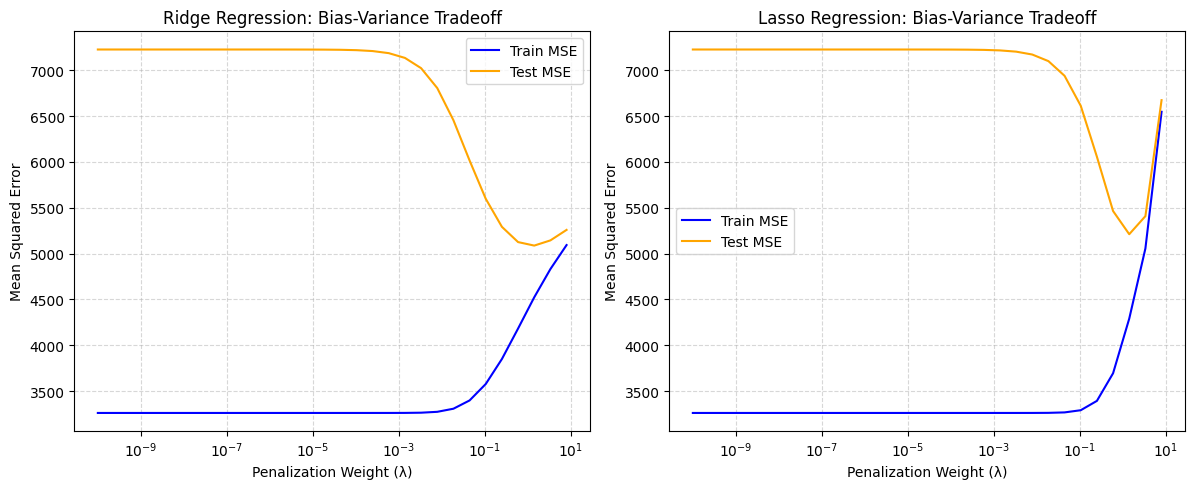

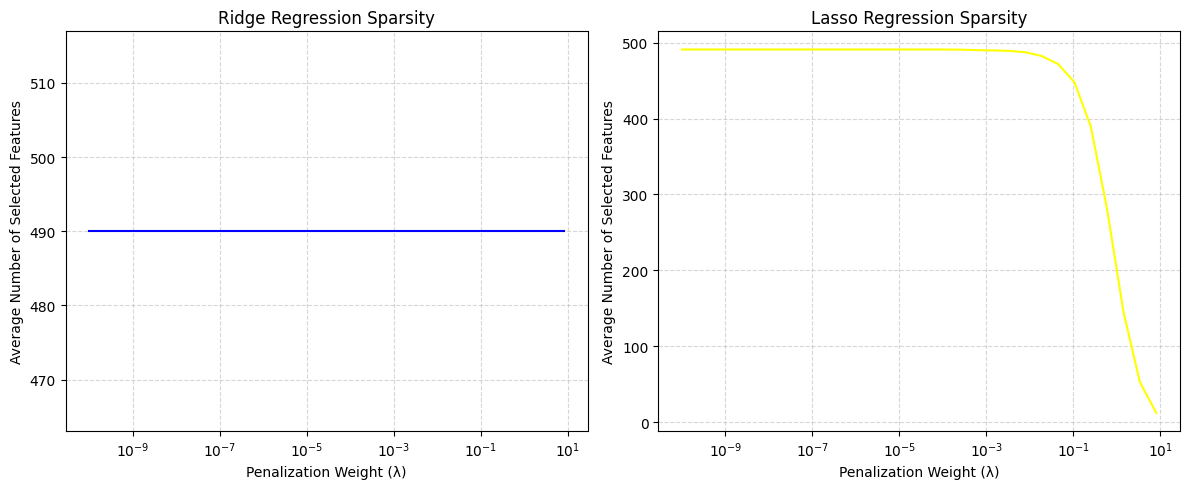

In [ ]:
plt.figure(figsize=(18, 5))

# Plot 1: Ridge MSE
plt.subplot(1, 3, 1)
plt.plot(lambdas, ridge_train_mse, label='Train MSE', color='blue')
plt.plot(lambdas, ridge_test_mse, label='Test MSE', color='orange')
plt.xscale('log')
plt.xlabel('Penalization Weight (λ)')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Regression: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Plot 2: Lasso MSE
plt.subplot(1, 3, 2)
plt.plot(lambdas, lasso_train_mse, label='Train MSE', color='blue')
plt.plot(lambdas, lasso_test_mse, label='Test MSE', color='orange')
plt.xscale('log')
plt.xlabel('Penalization Weight (λ)')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Regression: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

# Ridge sparsity
plt.subplot(1,2,1)
plt.plot(lambdas, ridge_features_count, color='blue')
plt.xscale('log')
plt.xlabel('Penalization Weight (λ)')
plt.ylabel('Average Number of Selected Features')
plt.title('Ridge Regression Sparsity')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Lasso sparsity
plt.subplot(1,2,2)
plt.plot(lambdas, lasso_features_count, label='Lasso features count', color='yellow')
plt.xscale('log')
plt.xlabel('Penalization Weight (λ)')
plt.ylabel('Average Number of Selected Features')
plt.title('Lasso Regression Sparsity')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()